In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
merged_df = pd.read_csv(
    "/content/global_water_risk_intelligence.csv"
)

merged_df.head()

,country,iso3,population,estimated_greywater_m3_year,greywater_tons_per_hour,reuse_efficiency_pct,estimated_reused_water_m3_year,reuse_effectiveness_class,untapped_reuse_m3_year,predicted_reuse_class,urban_population_pct,improved_reuse_score,improved_reuse_class,water_stress_pct,water_risk_score,water_risk_class
0,Africa Eastern and Southern,AFE,750491370,37524568500,4.283627e+06,33.090509,1.241707e+10,Moderate,2.510750e+10,Moderate,37.772301,34.963226,Moderate,NaN,NaN,NaN
1,Africa Western and Central,AFW,509398589,25469929450,2.907526e+06,76.303573,1.943447e+10,Highly Effective,6.035463e+09,Highly Effective,52.282908,66.695307,Good,NaN,NaN,NaN
2,Arab World,ARB,482105978,24105298900,2.751746e+06,59.899546,1.443896e+10,Good,9.666334e+09,Good,59.569941,59.767704,Good,NaN,NaN,NaN
3,Caribbean small states,CSS,4519904,225995200,2.579854e+04,49.899386,1.127702e+08,Good,1.132250e+08,Good,50.102089,49.980467,Moderate,NaN,NaN,NaN
4,Central Europe and the Baltics,CEB,100183707,5009185350,5.718248e+05,16.701398,8.366040e+08,Low,4.172581e+09,Low,61.697079,34.699670,Moderate,NaN,NaN,NaN


In [3]:
merged_df["infrastructure_intelligence_score"] = (
    merged_df["reuse_efficiency_pct"] * 0.30
    +
    merged_df["urban_population_pct"] * 0.20
    +
    merged_df["water_stress_pct"] * 0.30
    +
    merged_df["improved_reuse_score"] * 0.20
)

In [4]:
merged_df["infrastructure_class"] = pd.cut(
    merged_df["infrastructure_intelligence_score"],
    bins=[0, 25, 50, 75, 1000],
    labels=[
        "Developing",
        "Emerging",
        "Advanced",
        "Highly Advanced"
    ]
)

In [5]:
top_infra = merged_df.sort_values(
    by="infrastructure_intelligence_score",
    ascending=False
).head(20)

top_infra[
    [
        "country",
        "reuse_efficiency_pct",
        "urban_population_pct",
        "water_stress_pct",
        "infrastructure_intelligence_score",
        "infrastructure_class"
    ]
]

,country,reuse_efficiency_pct,urban_population_pct,water_stress_pct,infrastructure_intelligence_score,infrastructure_class
141,Kuwait,23.883672,100.000000,3850.500000,1193.181142,NaN
239,United Arab Emirates,18.283301,85.668070,1509.933333,484.646046,Highly Advanced
201,Saudi Arabia,11.310497,84.296239,974.166667,320.603356,Highly Advanced
148,Libya,8.860906,87.864720,817.142857,273.466559,Highly Advanced
194,Qatar,30.427234,99.283533,431.034483,169.889172,Highly Advanced
249,"Yemen, Rep.",68.975709,36.570798,169.761905,90.138193,Highly Advanced
134,Jordan,75.718228,92.682237,105.202127,89.313320,Highly Advanced
183,Oman,70.800452,79.570297,116.714286,87.030159,Highly Advanced
139,"Korea, Rep.",77.883656,81.164555,85.221833,81.003761,Highly Advanced
130,Israel,36.305825,91.508957,131.998965,80.470644,Highly Advanced


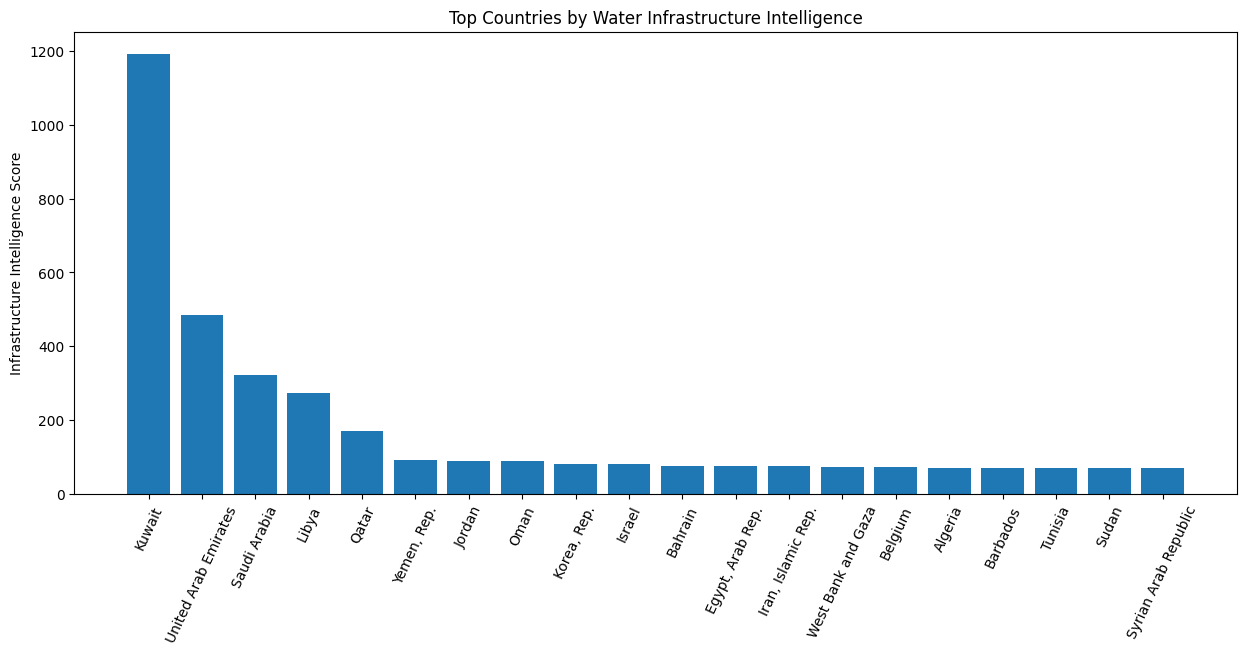

In [6]:
plt.figure(figsize=(15,6))

plt.bar(
    top_infra["country"],
    top_infra["infrastructure_intelligence_score"]
)

plt.xticks(rotation=65)

plt.ylabel("Infrastructure Intelligence Score")

plt.title(
    "Top Countries by Water Infrastructure Intelligence"
)

plt.show()

In [7]:
vulnerable = merged_df.sort_values(
    by="infrastructure_intelligence_score",
    ascending=True
).head(20)

vulnerable[
    [
        "country",
        "water_stress_pct",
        "reuse_efficiency_pct",
        "infrastructure_class"
    ]
]

,country,water_stress_pct,reuse_efficiency_pct,infrastructure_class
237,Uganda,5.827996,6.823697,Developing
72,Central African Republic,0.335648,5.414159,Developing
205,Sierra Leone,0.495794,5.689779,Developing
68,Cambodia,1.036545,10.591298,Developing
66,Burundi,10.192868,15.569317,Developing
213,South Sudan,4.226076,21.820198,Developing
171,Namibia,0.314668,6.244087,Developing
208,Slovak Republic,2.425230,5.379619,Developing
79,"Congo, Dem. Rep.",0.226884,13.690179,Developing
57,Bhutan,1.413808,19.698715,Developing


In [8]:
merged_df.to_csv(
    "global_infrastructure_intelligence.csv",
    index=False
)

print("Saved successfully")

Saved successfully
